In [1]:
import numpy as np
import pandas as pd

### Pandas Series

A pandas series is like a coumn in a table. it is a 1-D array holding any type of data.

### series from lists

In [2]:
# string
country = ['India', 'USA', 'UK','Canada','China']

pd.Series(country)

0     India
1       USA
2        UK
3    Canada
4     China
dtype: object

In [3]:
# integer
runs = [13,24,56,42,78]

pd.Series(runs)

0    13
1    24
2    56
3    42
4    78
dtype: int64

In [4]:
# custom index
marks = [87,69,45,39,91]
subjects = ['maths','english','geography','hindi','science']

pd.Series(marks, index=subjects, name="zaid's marks")

maths        87
english      69
geography    45
hindi        39
science      91
Name: zaid's marks, dtype: int64

### series from dict

In [5]:
marks = {
    'maths' : 67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks)
print(marks_series)

maths       67
english     57
science     89
hindi      100
dtype: int64


### series attributes

In [6]:
#size
print(marks_series.size)

#dtype
print(marks_series.dtype)

#name
print(marks_series.name)

#is_unqiue
print(marks_series.is_unique)

#index
print(marks_series.index)

#values
print(marks_series.values)

4
int64
None
True
Index(['maths', 'english', 'science', 'hindi'], dtype='object')
[ 67  57  89 100]


### series using read_csv

In [7]:
# with one col
subs = pd.read_csv("subs.csv").squeeze() # by default it is stored in dataframe format .squeeze() turns it into a series
print(subs,"\n \n")

kohli = pd.read_csv("kohli_ipl.csv", index_col = 'match_no').squeeze()
print("kohli runs in matches: \n",kohli)

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64 
 

kohli runs in matches: 
 match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


### series methods

In [8]:
# head and tail
# you can also give value inside head() and tail to print specific number of rows
print("first five rows: \n")
print(subs.head(), "\n \n")

print("last five rows: \n")
print(subs.tail(),"\n \n")

print("any one random row: \n")
print(subs.sample())

first five rows: 

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64 
 

last five rows: 

360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, dtype: int64 
 

any one random row: 

80    88
Name: Subscribers gained, dtype: int64


In [9]:
movies = pd.read_csv("bollywood.csv", index_col="movie").squeeze()
print("movies series: \n")
print(movies, "\n \n")

print("number of movies every actor did: \n")
print(movies.value_counts())


movies series: 

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object 
 

number of movies every actor did: 

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Diganth              1
Parveen Kaur         1
Seema Azmi           1
Akanksha Puri        1
Edwin Fernandes      1
Name: count,

In [10]:
print("runs of kohli in every match in sorted order (by runs): \n")
print(kohli.sort_values(),"\n \n")  # here you can give ascending =  True/False (to give firection of sorting)

print("most run made by kohli in a single match: \n")
print(kohli.sort_values(ascending=False).head(1).values[0])

print("least run made by kohli in a single match: \n")
print(kohli.sort_values(ascending=False).tail(1).values[0])



runs of kohli in every match in sorted order (by runs): 

match_no
87       0
211      0
207      0
206      0
91       0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64 
 

most run made by kohli in a single match: 

113
least run made by kohli in a single match: 

0


In [11]:
# sort_index
# similar to sort_values but instead of values it sorts the index_value

print("sorting movies in ascending order (0-100 & a-z): \n")
print(movies.sort_index())

sorting movies in ascending order (0-100 & a-z): 

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object


### series maths methods

In [12]:
# count() gives no of items in a series
#size() -> includes missing values
#count() -> does not include missing values 

print(kohli.count())  # this will not include any missing value

215


In [13]:
# sum()
print("number of total subscribers gained in a year: \n")
print(subs.sum())

# there are similar other mathematical methods like product() mean() mode() std() var() min() max()

number of total subscribers gained in a year: 

49510


In [14]:
# describe()

print(kohli.describe())

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64


### series indexing (reading methods)

In [15]:
# integer indexing
x = pd.Series([12,13,14,35,46,57,68,79,9])
print(x[0])  # first item in series

# NOTE: series does not have negative indexing like x[-1] this is not possible in series

12


In [16]:
# slicing 

print("data of kohli maatches from match number 5 to 16: \n")
print(kohli[4:16])

data of kohli maatches from match number 5 to 16: 

match_no
5      1
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
16     2
Name: runs, dtype: int64


In [17]:
# fancy indexing

print("data of matches of kohli (1,3,5,5) matches: \n")
print(kohli[[1,3,5,7]])

data of matches of kohli (1,3,5,5) matches: 

match_no
1     1
3    13
5     1
7    34
Name: runs, dtype: int64


### Editing series (writing methods)

In [18]:
# using indexing
marks_series.name = "zaid's marks"
print(marks_series)

marks_series["maths"] = 100
print(marks_series)

maths       67
english     57
science     89
hindi      100
Name: zaid's marks, dtype: int64
maths      100
english     57
science     89
hindi      100
Name: zaid's marks, dtype: int64


In [19]:
# slicing
print(kohli[2:5])

print("changing runs of matches 3,4,5 :\n")
kohli[2:5]= [100,40,50]
print(kohli[2:5])

match_no
3    13
4    12
5     1
Name: runs, dtype: int64
changing runs of matches 3,4,5 :

match_no
3    100
4     40
5     50
Name: runs, dtype: int64


In [20]:
# fancy indexing
print(kohli.head(10))
kohli[[1,7,9]] = [0,0,0] # here 0,1,7 are not indexes they are labels
print(kohli.head(10))

match_no
1       1
2      23
3     100
4      40
5      50
6       9
7      34
8       0
9      21
10      3
Name: runs, dtype: int64
match_no
1       0
2      23
3     100
4      40
5      50
6       9
7       0
8       0
9       0
10      3
Name: runs, dtype: int64


### series with python functionalities

In [23]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs)) # gives ans in form of list


365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__firstlineno__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rd

In [25]:
# type conversion
print(list(marks_series))
print(dict(marks_series))

[100, 57, 89, 100]
{'maths': np.int64(100), 'english': np.int64(57), 'science': np.int64(89), 'hindi': np.int64(100)}


In [27]:
# membership operator (in operator)

print('2 States (2014 film)' in movies)
print('Alia Bhatt' in movies.values)

True
True


In [28]:
# looping

for i in movies:
    print(i)

Vicky Kaushal
Vicky Ahuja
Anupam Kher
Emraan Hashmi
Mona Ambegaonkar
Geetika Vidya Ohlyan
Arshad Warsi
Radhika Apte
Kangana Ranaut
Nawazuddin Siddiqui
Ali Asgar
Ranveer Singh
Prit Kamani
Ajay Devgn
Sushant Singh Rajput
Amitabh Bachchan
Abhimanyu Dasani
Talha Arshad Reshi
Nawazuddin Siddiqui
Garima Agarwal
Rasika Agashe
Barun Sobti
Akshay Kumar
Zaheer Iqbal
Vidyut Jammwal
Deepika Amin
Manav Kaul
Naseeruddin Shah
Varun Dhawan
Shreyas Talpade
Tiger Shroff
Boman Irani
Ajay Devgn
Arjun Kapoor
Gavie Chahal
Prabhu Deva
Shahid Kapoor
Ayushmann Khurrana
Anupam Kher
Karanvir Bohra
Hrithik Roshan
Jimmy Sheirgill
John Abraham
Rishi Kapoor
Kangana Ranaut
Natalia Janoszek
Diljit Dosanjh
Sidharth Malhotra
Rajeev Khandelwal
Zaira Wasim
Akshay Kumar
Jacqueline Fernandez
Ayushmann Khurrana
Akshaye Khanna
Sonam Kapoor
Karan Deol
Sanjay Dutt
Bhavesh Kumar
Sanaya Irani
Ayushmann Khurrana
Siddhanth Kapoor
Akshay Kumar
Taapsee Pannu
Rajkummar Rao
Sunny Singh Nijjar
Neil Nitin Mukesh
Suraj Pancholi
Boman Iran

In [29]:
# we can also use arithmatic and relational operators in pandas

### boolean indexing on series


In [30]:
# find no of 50's and 100's scored by kohli

kohli >= 50

match_no
1      False
2      False
3       True
4      False
5       True
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

In [35]:
print(kohli[kohli >= 50].size)

52


In [39]:
# find actors who have done more than 30 movies

num_movies = movies.value_counts()
print(num_movies,"\n \n")
print(num_movies[num_movies > 20])

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Diganth              1
Parveen Kaur         1
Seema Azmi           1
Akanksha Puri        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64 
 

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64


### plotting graphs on series

<Axes: >

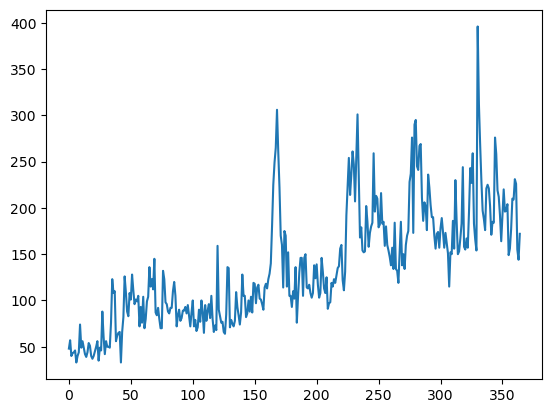

In [40]:
subs.plot()